# Problem Statement
- Startup developed a light weight water bottle
- Target Audience - School Kids aged 6-16.
- As a Marketing Associate, identify the most effective channels and craft compelling content
- Budget - 2000 USD

Build an agentic system that can help with the same using sequential chat.

In [1]:
import autogen
from autogen import AssistantAgent
from IPython.display import display, Markdown

In [2]:
from dotenv import load_dotenv
load_dotenv('/Users/janvi/Downloads/AutoGen Handouts/.env')

True

# Sequential Chat

In [3]:
strategy_config_list = {
    "config_list": [{"model": "gpt-4o-mini", "temperature": 0.3}]
}

In [4]:
strategy_creator = autogen.AssistantAgent(
    name="strategy_creator",
    llm_config=strategy_config_list,
    system_message=""""You are a logical marketing manager tasked with crafting a marketing strategy. 
    Gather details on the product, target audience, and budget. Then identify the best marketing channels 
    which will get that product maximum visibility."
    """
)

In [5]:
content_config_list = {
    "config_list": [{"model": "gpt-4o-mini", "temperature": 0.6}]
}

In [6]:
content_creator = autogen.AssistantAgent(
    name="content_creator",
    llm_config=content_config_list,
    system_message=""""You are Content Executor, a creative AI agent. 
    Your task is to craft engaging, channel-specific content that aligns with the marketing strategy, 
    ensuring it captures attention and resonates with the target audience."
    """
)

Define the user proxy agent:
1. Save UserProxyAgent in the user_proxy variable and name it "User".
2. **human_input_mode** - Sets  frequency at which the user can input. 
3. **is_termination_msg** - A lambda function which determines whether a message is a termination message. In our case:
    - The message has content (x.get("content", "")), and
    - The content ends with the string "TERMINATE" after stripping any trailing whitespace.
4. Finally **code_execution=False** disables code execution capability for this proxy agent.

In [7]:
user_proxy = autogen.UserProxyAgent(
    name="User",
    human_input_mode="ALWAYS",
    is_termination_msg=lambda x: x.get("content", "") and x.get("content", "").rstrip().endswith("TERMINATE"),
    code_execution_config=False)

In [8]:
product_details = [
    """Water bottle for school children under the age of 16 years. The marketing budget is 2000 USD""",
]

In [9]:
writing_task = ["""Write an engaging content for the mentioned product and channel"""]

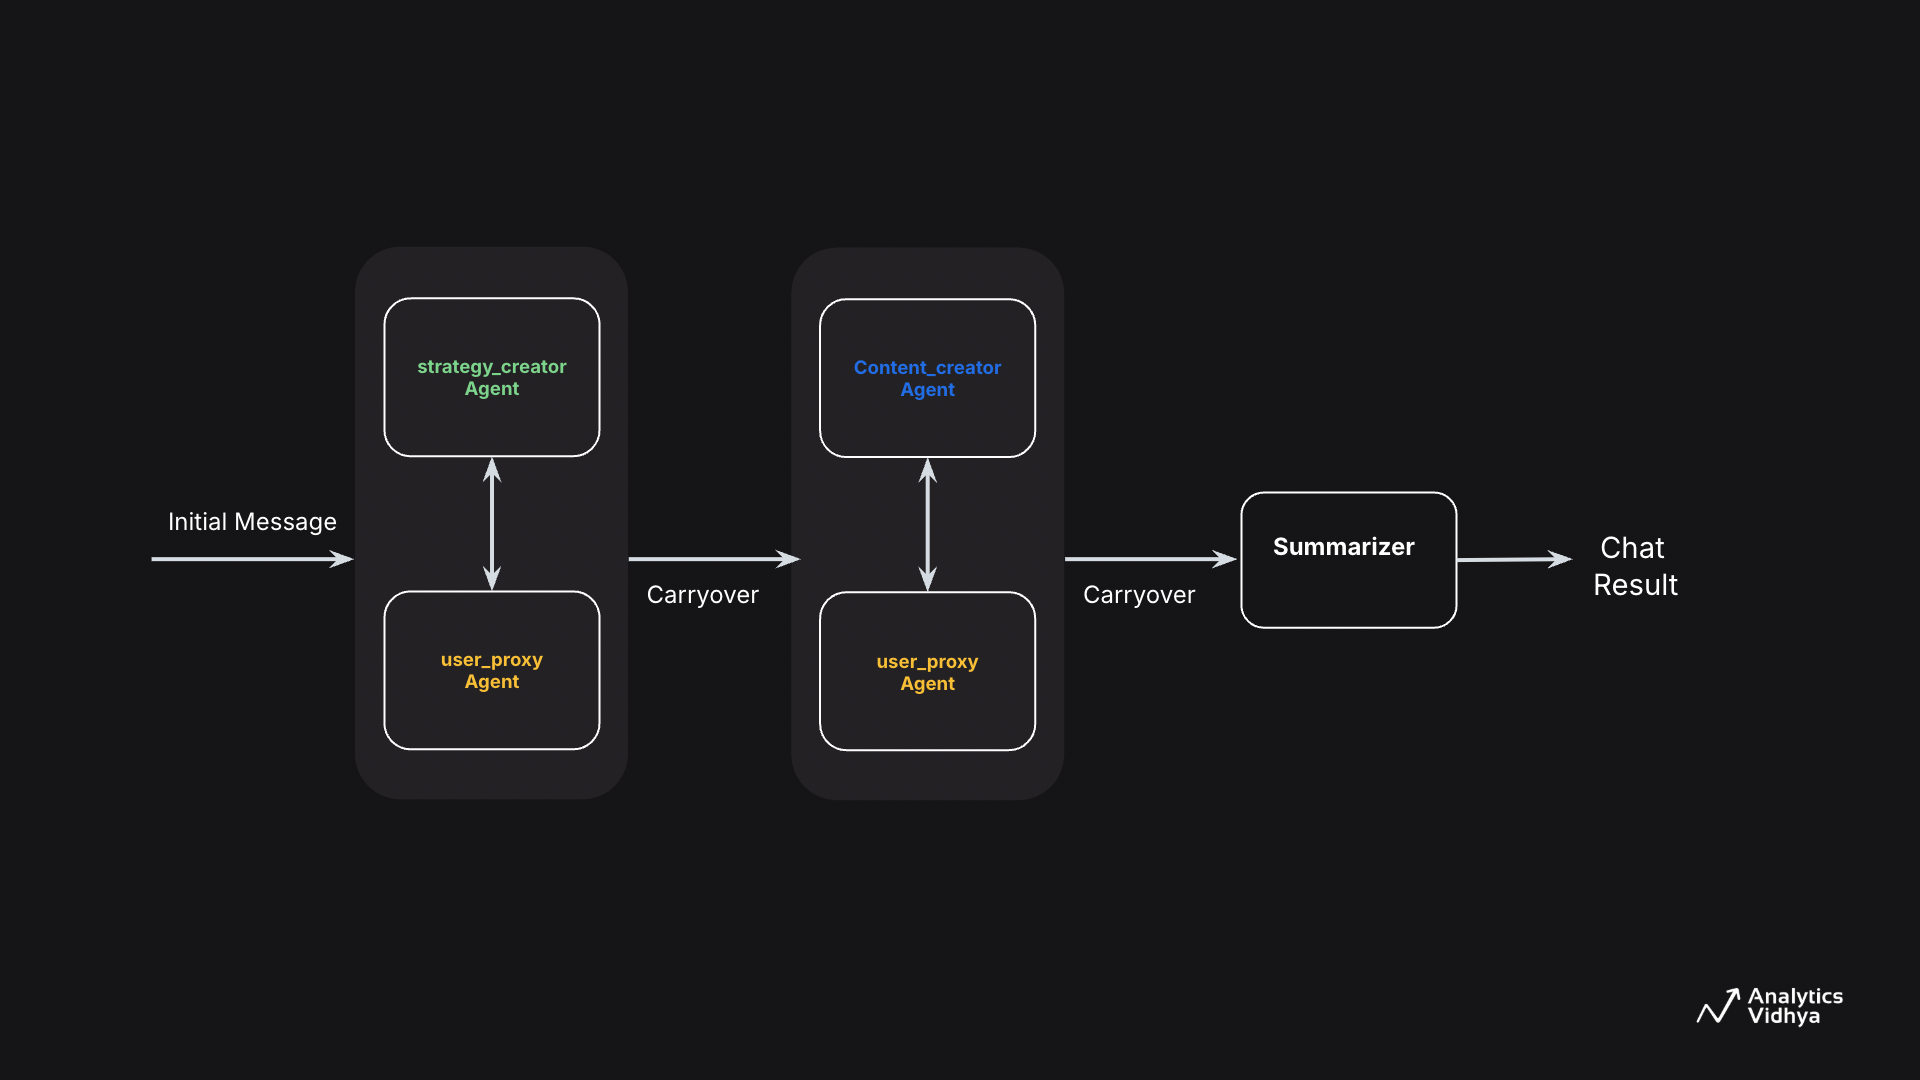

1. First, **user_proxy** agent sends the message to **strategy_creator** agent. The message sent by user_proxy agent is saved in the "product_details" list. We will be clearing the history of the conversation and printing the the conversation between the agents by setting "silence=False".

2. Then the summary of the chat above is carried over to the next conversation which happens between the **user_proxy** agent and **content_creator** agent. The user_proxy agent sends the message stored in the "writer_task" skill. And we generate the summary as the last message.

In [10]:
chat_results = autogen.initiate_chats(
    [
        {
            "sender": user_proxy,
            "recipient": strategy_creator,
            "message": product_details[0],
            "clear_history": True,
            "silent": False,
            "summary_method": "last_msg",
        },
        {
            "sender": user_proxy,
            "recipient": content_creator,
            "message": writing_task[0],
            "summary_method": "last_msg",
        },
    ]
)


********************************************************************************
Starting a new chat....

********************************************************************************
User (to strategy_creator):

Water bottle for school children under the age of 16 years. The marketing budget is 2000 USD

--------------------------------------------------------------------------------
strategy_creator (to User):

Great! Let's break down the marketing strategy for the water bottle targeted at school children under the age of 16.

### Product Details:
- **Product**: Water bottle
- **Features**: 
  - Durable and spill-proof design
  - Fun colors and designs appealing to children
  - BPA-free materials
  - Easy-to-carry (e.g., with a strap or handle)
  - Possibly customizable (e.g., with names or stickers)
  
### Target Audience:
- **Primary Audience**: School children aged 6-16 years
- **Secondary Audience**: Parents and guardians who make purchasing decisions
- **Key Considerations**

In [11]:
len(chat_results)

2

In [12]:
display(Markdown(chat_results[0].summary))

It seems that your messages are still coming through blank. If you have any questions or need assistance, please try typing your message again. I'm here to help with anything you need!

In [13]:
display(Markdown(chat_results[1].summary))

Of course! Please provide the specific product and channel you would like me to create content for, and I’ll be happy to craft something engaging for you.

- Tool Use: To help Agents integrate tools for task execution.
- Code Execution: To allow agents to execute code to solve problems.